In [19]:
# Cell 1A: Imports and Basic Helper Functions
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Rectangle
import os # For creating directories

def parse_line_kv_only(line: str):
    """Parses a comma-separated key-value string line into a dictionary."""
    result = {}
    for kv in line.split(","):
        if "=" in kv: k, v = kv.split("="); result[k] = v
    return result

def aggregate_dicts(dicts: list[dict]):
    """Aggregates a list of dictionaries based on a composite key."""
    aggregated = defaultdict(lambda: defaultdict(list))
    for d_item in dicts:
        key = (d_item.get("param"), d_item.get("noise_level"), d_item.get("n_pts"), d_item.get("n_indivs"))
        for k, v in d_item.items():
            if k not in {"param", "noise_level", "n_pts", "n_indivs"}: aggregated[key][k].append(v)
    return dict(aggregated)

def aggregate(param_char):
    """Loads data from a file and aggregates it."""
    filename = f"results_{param_char.replace('\'','')}_v2.txt"
    try:
        with open(filename, "r") as f:
            lines = [line.strip() for line in f.readlines()]
            results = [parse_line_kv_only(line) for line in lines]
            agg = aggregate_dicts(results)
        return agg
    except FileNotFoundError:
        print(f"Warning: Data file {filename} not found for parameter {param_char}.")
        return None

def get_cmap_bounds(params, include_NR=True):
    """Computes min/max of medians for specific keys for a list of parameters."""
    keys_to_check = []
    base_metrics = ["param_relative_err", "rms_log_T", "rms_log_C"]
    outcomes = ["CR"]
    if include_NR: outcomes.append("NR")
    for bm in base_metrics:
        for oc in outcomes: keys_to_check.append(f"{bm}_{oc}")
    if "param_relative_err" not in keys_to_check: keys_to_check.append("param_relative_err")

    bounds = {key: [float("inf"), float("-inf")] for key in keys_to_check}
    for param_char in params: 
        agg_data = aggregate(param_char) 
        if agg_data is None: continue
        for ddk_tuple in agg_data: 
            for mk in keys_to_check:
                if mk in agg_data[ddk_tuple]:
                    vf_vals = []
                    for x_str in agg_data[ddk_tuple][mk]:
                        try: 
                            v_f = float(x_str)
                            if not np.isnan(v_f): vf_vals.append(v_f)
                        except (ValueError, TypeError): pass 
                    if vf_vals: 
                        med_val = np.median(vf_vals)
                        if not np.isnan(med_val): 
                            bounds[mk][0] = min(bounds[mk][0], med_val); bounds[mk][1] = max(bounds[mk][1], med_val)
    final_b = {}
    for kb in keys_to_check:
        min_v, max_v = bounds[kb]
        final_b[kb] = (None, None) if min_v == float("inf") or max_v == float("-inf") else (min_v, max_v)
    return final_b

In [20]:
# Cell 1B: Core Heatmap Drawing Utilities
from collections import defaultdict # Should be in 1A, but for standalone running of this cell
import numpy as np # Should be in 1A
import matplotlib.pyplot as plt # Should be in 1A
from matplotlib.colors import LogNorm, Normalize # Should be in 1A
from matplotlib.patches import Rectangle # Should be in 1A
# os module might be needed if save_path used directly here (not typical for helpers)
import os 

def enhanced_plot_heatmap(heatmap, x_labels, y_labels, title, 
                          log_scale=True, cmap='viridis',
                          vmin=None, vmax=None, highlight_thresh=None, save_fname=None):
    # Kept as per original code structure, not primary for Cell 3/4 combined plots
    fig, ax = plt.subplots(figsize=(10, 6)); fig.patch.set_facecolor('white')
    hm_arr = np.array(heatmap)
    eff_vmin_log = vmin if not (log_scale and vmin is not None and vmin <= 0) else None
    log_vmin_def, log_vmax_def = 1e-1, 1.0
    if np.any(hm_arr[np.nonzero(hm_arr)]):
        valid_data_for_log = hm_arr[hm_arr > 0]
        if valid_data_for_log.size > 0:
            log_vmin_def, log_vmax_def = np.nanmin(valid_data_for_log), np.nanmax(valid_data_for_log)
            if log_vmin_def >= log_vmax_def: log_vmax_def = log_vmin_def * 10 if log_vmin_def > 0 else 1.0
    
    norm_vmin_def, norm_vmax_def = 0.0, 1.0
    if not np.all(np.isnan(hm_arr)): 
        temp_min, temp_max = np.nanmin(hm_arr), np.nanmax(hm_arr)
        if not (np.isnan(temp_min) or np.isnan(temp_max)):
             norm_vmin_def, norm_vmax_def = temp_min, temp_max
             if norm_vmin_def >= norm_vmax_def: norm_vmax_def = norm_vmin_def + 1.0

    norm = LogNorm(vmin=eff_vmin_log or log_vmin_def, vmax=vmax or log_vmax_def) if log_scale \
           else Normalize(vmin=vmin or norm_vmin_def, vmax=vmax or norm_vmax_def)

    cax_img = ax.imshow(hm_arr, cmap=cmap, aspect='auto', norm=norm)
    ax.add_patch(Rectangle((-0.5,-0.5), hm_arr.shape[1], hm_arr.shape[0], fill=False, ec='black', lw=2))
    for sp in ax.spines.values(): sp.set_edgecolor('black'); sp.set_linewidth(1.5)
    ax.set_xticks(np.arange(len(x_labels))); ax.set_yticks(np.arange(len(y_labels)))
    ax.set_xticklabels(x_labels); ax.set_yticklabels(y_labels)
    ax.set_xlabel("n_pts"); ax.set_ylabel("noise_level"); ax.set_title(title, pad=12, fs=12, weight='bold')
    if highlight_thresh is not None: pass 
    cbar = fig.colorbar(cax_img, ax=ax, pad=0.02); cbar.set_label('Median Value', rotation=270, labelpad=15)
    plt.tight_layout()
    if save_fname: fig.savefig(save_fname, dpi=300, bbox_inches='tight')
    plt.show()


def staircase_boundary(heatmap, threshold):
    """Finds staircase boundary. diff variable controls spacing from border."""
    x_pos = [] # Stores the x-coordinate of the boundary for each row, from bottom row upwards
    for i in range(heatmap.shape[0]-1, -1, -1): # Iterate heatmap rows from bottom up
        r = heatmap[i,:]; 
        # Find indices of cells in current row that are <= threshold and not NaN
        idx = np.where((~np.isnan(r)) & (r <= threshold))[0] 
        # If such cells exist, boundary is to the right of the rightmost one. Otherwise, at far left.
        x_pos.append((1 + idx[-1] if len(idx) > 0 else 0) - 0.5) 
    
    # Reverse x_pos to go from top row's boundary to bottom row's boundary
    proc_x_pos = list(reversed(x_pos)) 
    
    if proc_x_pos:
        vtx = [(-0.5, heatmap.shape[0]-0.5)]; # Start path at top-left of heatmap plot area
        lx = -0.5 # last_x_coord processed
        for i, cx_b in enumerate(proc_x_pos): # cx_b is the ideal x-boundary for current row i
            # Enforce monotonicity: boundary can only move right or stay vertical as we go down rows
            cx_b = max(lx, cx_b); 
            
            y_top_current_row_plotcoords = heatmap.shape[0]-0.5-i; 
            y_bottom_current_row_plotcoords = y_top_current_row_plotcoords-1 # Bottom of current cell / top of cell below
            
            # If boundary moved right for this new row (cx_b > lx), add horizontal segment
            if cx_b > lx : 
                 vtx.append((lx, y_top_current_row_plotcoords)) 
            # Add point at new_x, top_of_current_row_cell
            vtx.append((cx_b, y_top_current_row_plotcoords))   
            # Add vertical segment down along new_x to bottom of current row cell
            vtx.append((cx_b, y_bottom_current_row_plotcoords)) 
            lx = cx_b # Update last_x for next iteration
        
        # Connect to bottom border of heatmap
        vtx.append((lx, -0.5)) 
        if lx < heatmap.shape[1]-0.5: # If boundary doesn't reach right edge of heatmap
             vtx.append((heatmap.shape[1]-0.5, -0.5)) # Extend to right edge along bottom border
        
        diff = 0.035 # Controls inward shift from cell edges for visibility
        adj_vtx = []
        for vx, vy in vtx:
            nvx, nvy = vx, vy
            if vx == -0.5: nvx += diff
            elif vx == heatmap.shape[1]-0.5: nvx -= diff
            if vy == -0.5: nvy += diff
            elif vy == heatmap.shape[0]-0.5: nvy -= diff
            adj_vtx.append((nvx, nvy))
        return adj_vtx
    return []

def plot_single_heatmap_on_ax(ax, heatmap_data, x_labels, y_labels, 
                              vertices_T=None, vertices_C=None,
                              log_scale=True, cmap='viridis', vmin=None, vmax=None):
    """Plots a single heatmap. No default Y-label set here."""
    hm_arr = np.array(heatmap_data); eff_vmin = vmin
    if log_scale and vmin is not None and vmin <= 0: eff_vmin = None 
    norm = LogNorm(vmin=eff_vmin, vmax=vmax) if log_scale else Normalize(vmin=vmin, vmax=vmax)
    ax.imshow(hm_arr, cmap=cmap, aspect='auto', norm=norm)
    ax.add_patch(Rectangle((-0.5,-0.5), hm_arr.shape[1],hm_arr.shape[0],fill=False,ec='black',lw=1))
    for sp in ax.spines.values(): sp.set_edgecolor('black'); sp.set_linewidth(1.5)
    ax.set_xticks(np.arange(len(x_labels))); ax.set_yticks(np.arange(len(y_labels)))
    ax.set_xticklabels(x_labels, fontsize=8); ax.set_yticklabels(y_labels, fontsize=8)
    lw, alp = 3, 0.95   
    if vertices_T: xt,yt=zip(*vertices_T); ax.plot(xt,yt,color='red',lw=lw,ls='-',alpha=alp)
    if vertices_C: xc,yc=zip(*vertices_C); ax.plot(xc,yc,color='magenta',lw=lw,ls='-',alpha=alp)

def build_heatmap_data(aggregated_for_param, metric_key_template, outcome, 
                       noise_levels, n_pts_values):
    """Builds a 2D numpy array (heatmap)."""
    hm = np.full((len(noise_levels), len(n_pts_values)), np.nan)
    act_mk = metric_key_template.format(outcome=outcome) if "{outcome}" in metric_key_template else metric_key_template
    if not aggregated_for_param or not aggregated_for_param.keys(): return hm
    p_char = list(aggregated_for_param.keys())[0][0] 
    for i, nl in enumerate(noise_levels):
        for j, np_val in enumerate(n_pts_values):
            key_tup = None
            for ak_tup in aggregated_for_param.keys():
                if str(ak_tup[0])==str(p_char) and str(ak_tup[1])==str(nl) and str(ak_tup[2])==str(np_val):
                    key_tup=ak_tup; break
            if key_tup and act_mk in aggregated_for_param[key_tup]:
                vals_str = aggregated_for_param[key_tup][act_mk]; f_vals = []
                for xs in vals_str:
                    if xs is not None:
                        try: 
                            v=float(xs)
                            if not np.isnan(v): f_vals.append(v)
                        except ValueError: pass # Ignore non-float strings
                if f_vals: hm[i,j]=np.median(f_vals)
    return hm

In [21]:
# Cell 1C: Main Figure Generation Functions

def plot_figure_cell3(all_params_list, aggregated_data_map, 
                      row_bounds_dict, log_scale, save_path):
    """
    Cell 3: 3x5. Cbar per row (no label). X-ticks/labels ONLY on bottom row. Single "Number of Points" supxlabel.
    Y-ticks/labels ONLY on first col. Single "Obs. Coeff. of Var." supylabel. Row titles above first plot of row.
    Tick MARKS also hidden on inner/upper plots.
    """
    nrows = 3; ncols = len(all_params_list)
    row_title_fontsize = 10 
    sup_label_fontsize = 10

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.6, nrows * 2.6 + 0.9), 
                             sharex='col', sharey='row', squeeze=False)
    fig.patch.set_facecolor('white'); cmap = 'viridis'; outcome_code = "CR" 
    
    row_metric_templates = ["param_relative_err_{outcome}", "rms_log_{outcome}_T", "rms_log_{outcome}_C"]
    row_descriptive_texts = [ 
        "MRE of Estimated Parameter", "Median RMSE log(T) Error", "Median RMSE log(C) Error" 
    ]
    
    common_nl, common_np = None, None
    for p_name in all_params_list: 
        agg_d = aggregated_data_map.get(p_name)
        if agg_d and isinstance(agg_d,dict) and agg_d:
            k_ex = list(agg_d.keys())[0]
            try:
                common_nl = sorted(list(set(str(k[1]) for k in agg_d.keys())), key=float)
                common_np = sorted(list(set(str(k[2]) for k in agg_d.keys())), key=float, reverse=True); break
            except (TypeError, ValueError) as e: print(f"Warn: Cell 3 sort error {e}")
    if common_nl is None or common_np is None: print("Err: Cell 3 common levels fail. Close fig."); plt.close(fig); return

    for c_idx, p_val in enumerate(all_params_list):
        agg_param_d = aggregated_data_map.get(p_val)
        if not agg_param_d:
            for r_idx_val_inner in range(nrows): axes[r_idx_val_inner,c_idx].axis('off'); continue # renamed r_idx_val

        vt_d = build_heatmap_data(agg_param_d,"rms_log_{outcome}_T",outcome_code,common_nl,common_np)
        vc_d = build_heatmap_data(agg_param_d,"rms_log_{outcome}_C",outcome_code,common_nl,common_np)
        vT = None if np.all(np.isnan(vt_d)) else staircase_boundary(vt_d,0.3)
        vC = None if np.all(np.isnan(vc_d)) else staircase_boundary(vc_d,0.3)

        for r_idx, metric_tpl in enumerate(row_metric_templates):
            ax = axes[r_idx,c_idx]; mkey_s = metric_tpl.format(outcome=outcome_code)
            if mkey_s=="rms_log_C_CR" and mkey_s not in row_bounds_dict and "rms_log_CR_C" in row_bounds_dict: mkey_s = "rms_log_CR_C"
            elif mkey_s=="rms_log_T_CR" and mkey_s not in row_bounds_dict and "rms_log_CR_T" in row_bounds_dict: mkey_s = "rms_log_CR_T"
            
            r_vmin,r_vmax = row_bounds_dict.get(mkey_s,(None,None))
            if log_scale and r_vmin is not None and r_vmin <= 0: r_vmin=None
            hm_v = build_heatmap_data(agg_param_d,metric_tpl,outcome_code,common_nl,common_np)
            pvt,pvc = (vT,vC) if metric_tpl=="param_relative_err_{outcome}" else (vT,None) if metric_tpl=="rms_log_{outcome}_T" else (None,vC)
            
            plot_single_heatmap_on_ax(ax,hm_v,common_np,common_nl,vertices_T=pvt,vertices_C=pvc,
                                      log_scale=log_scale,cmap=cmap,vmin=r_vmin,vmax=r_vmax)
            
            ax.set_xlabel(""); ax.set_ylabel("") 
            # REMARK: X-tick MARKS and labels explicitly hidden for upper rows
            if r_idx < nrows - 1 : 
                ax.set_xticks([])      
                ax.set_xticklabels([]) 
            # REMARK: Y-tick MARKS and labels explicitly hidden for non-first columns
            if c_idx > 0: 
                ax.set_yticks([])       
                ax.set_yticklabels([])
            
            if c_idx == 0: # Set row titles on the first plot of each row
                ax.set_title(row_descriptive_texts[r_idx], fontsize=row_title_fontsize, loc='center', pad=8)
    
    fig.supxlabel("Number of Points", y=0.02, fontsize=sup_label_fontsize) # y adjusted
    fig.supylabel("Observation Coefficient of Variation", x=0.06, fontsize=sup_label_fontsize, va='center') 
    fig.subplots_adjust(left=0.15, right=0.80, bottom=0.10, top=0.90, hspace=0.35, wspace=0.10) # wspace reduced
    
    cbar_left_start = 0.83; cbar_width = 0.015
    for i in range(nrows): 
        mkey_cbar = row_metric_templates[i].format(outcome=outcome_code)
        if mkey_cbar=="rms_log_C_CR" and mkey_cbar not in row_bounds_dict and "rms_log_CR_C" in row_bounds_dict: mkey_cbar = "rms_log_CR_C"
        elif mkey_cbar=="rms_log_T_CR" and mkey_cbar not in row_bounds_dict and "rms_log_CR_T" in row_bounds_dict: mkey_cbar = "rms_log_CR_T"
        vmin_cb,vmax_cb = row_bounds_dict.get(mkey_cbar,(None,None))
        if log_scale and vmin_cb is not None and vmin_cb <=0: vmin_cb=None
        if vmin_cb is None or vmax_cb is None or (not (np.isinf(vmin_cb) or np.isinf(vmax_cb)) and vmin_cb >= vmax_cb):
            vmin_cb,vmax_cb=(0.1,1.0) if log_scale else (0.0,1.0)
            if vmin_cb>=vmax_cb: vmax_cb=vmin_cb+(0.9 if log_scale else 1.0)
        norm_cb=LogNorm(vmin=vmin_cb,vmax=vmax_cb) if log_scale else Normalize(vmin=vmin_cb,vmax=vmax_cb)
        sm_cb=plt.cm.ScalarMappable(cmap=cmap,norm=norm_cb); sm_cb.set_array([])
        row_axes_bbox = axes[i,0].get_position()
        cax_cb = fig.add_axes([cbar_left_start, row_axes_bbox.y0, cbar_width, row_axes_bbox.height])
        cb = fig.colorbar(sm_cb, cax=cax_cb)
        cb.set_label("", labelpad=1, fontsize=1) 
        cb.ax.tick_params(labelsize=7)

    if save_path: os.makedirs(os.path.dirname(save_path),exist_ok=True); fig.savefig(save_path,dpi=300,bbox_inches='tight'); print(f"Saved Cell3 to {save_path}")
    plt.show(); plt.close(fig)


def plot_figure_cell4(params_for_cols_list, aggregated_data_map, 
                      metric_to_plot_template, log_scale, save_path):
    """
    Cell 4: 2x3. Cbar per col (no label). X-ticks/labels ONLY on bottom row. Single "Number of Points" supxlabel.
    Y-labels "CR/NR Outcome" on first col. Y-ticks/labels ONLY on first col.
    REMARK: Heatmaps made WIDER. X/Y Tick MARKS also hidden on inner/upper plots.
    """
    nrows=2; ncols=len(params_for_cols_list)
    sup_label_fontsize = 10
    # REMARK: figsize and gridspec width_ratios adjusted for WIDER heatmaps.
    fig = plt.figure(figsize=(ncols*(5.5+0.2), nrows*3.2+0.4)) # Increased base width for plot+cbar group
    gs = fig.add_gridspec(nrows,ncols*2,width_ratios=([10,0.8]*ncols),hspace=0.15,wspace=0.75) # Plot gets more ratio, wspace adjusted

    fig.patch.set_facecolor('white'); cmap='viridis'
    outcomes_rows=["CR","NR"]; row_y_lbls=["CR Outcome","NR Outcome"]
    common_nl,common_np = None,None
    for p_name in params_for_cols_list:
        agg_d=aggregated_data_map.get(p_name)
        if agg_d and isinstance(agg_d,dict) and agg_d:
            k_ex=list(agg_d.keys())[0]
            try:
                common_nl=sorted(list(set(str(k[1]) for k in agg_d.keys())),key=float)
                common_np=sorted(list(set(str(k[2]) for k in agg_d.keys())),key=float,reverse=True); break
            except (TypeError,ValueError) as e: print(f"Warn: Cell4 sort error {e}")
    if common_nl is None or common_np is None: print("Err: Cell4 common levels fail. Close fig."); plt.close(fig); return

    for c_idx,p_item in enumerate(params_for_cols_list):
        p_noq=p_item.replace("'","")
        agg_p_item=aggregated_data_map.get(p_item)
        ax_cr = fig.add_subplot(gs[0, c_idx*2])
        ax_nr = fig.add_subplot(gs[1, c_idx*2], sharex=ax_cr) 
        ax_cbar = fig.add_subplot(gs[:, c_idx*2+1])
        if not agg_p_item: ax_cr.axis('off'); ax_nr.axis('off'); ax_cbar.axis('off'); continue
        
        col_data = []
        hm_cr = build_heatmap_data(agg_p_item,metric_to_plot_template,"CR",common_nl,common_np)
        if not np.all(np.isnan(hm_cr)): col_data.append(hm_cr[~np.isnan(hm_cr)])
        hm_nr = build_heatmap_data(agg_p_item,metric_to_plot_template,"NR",common_nl,common_np)
        if not np.all(np.isnan(hm_nr)): col_data.append(hm_nr[~np.isnan(hm_nr)])
        col_vmin,col_vmax = None,None
        if col_data:
            all_c_data = np.concatenate(col_data) if col_data else np.array([])
            v_c_data = all_c_data[np.isfinite(all_c_data)]
            if log_scale: v_c_data=v_c_data[v_c_data>0]
            if v_c_data.size > 0:
                col_vmin,col_vmax=np.min(v_c_data),np.max(v_c_data)
                if col_vmin>=col_vmax: col_vmin,col_vmax=None,None
        if col_vmin is None or col_vmax is None:
            col_vmin,col_vmax=(0.1,1.0) if log_scale else (0.0,1.0)
            if col_vmin>=col_vmax: col_vmax=col_vmin+(0.9 if log_scale else 1.0)

        for r_idx,outcome_v in enumerate(outcomes_rows):
            ax_p = ax_cr if r_idx==0 else ax_nr
            curr_hm = hm_cr if outcome_v=="CR" else hm_nr
            vt_d=build_heatmap_data(agg_p_item,"rms_log_{outcome}_T",outcome_v,common_nl,common_np)
            vc_d=build_heatmap_data(agg_p_item,"rms_log_{outcome}_C",outcome_v,common_nl,common_np)
            vT_s=None if np.all(np.isnan(vt_d)) else staircase_boundary(vt_d,0.3)
            vC_s=None if np.all(np.isnan(vc_d)) else staircase_boundary(vc_d,0.3)
            plot_single_heatmap_on_ax(ax_p,curr_hm,common_np,common_nl,vertices_T=vT_s,vertices_C=vC_s,
                                      log_scale=log_scale,cmap=cmap,vmin=col_vmin,vmax=col_vmax)
            ax_p.set_xlabel("") 
            # REMARK: X-tick MARKS AND labels explicitly hidden for upper row
            if r_idx < nrows - 1: 
                ax_p.set_xticks([])      
                ax_p.set_xticklabels([]) 
            # REMARK: Y-tick MARKS AND labels explicitly hidden for non-first columns
            if c_idx==0: 
                ax_p.set_ylabel(row_y_lbls[r_idx], fontsize=9) 
            else: 
                ax_p.set_ylabel("")
                ax_p.set_yticks([])      
                ax_p.set_yticklabels([])
        
        norm_c=LogNorm(vmin=col_vmin,vmax=col_vmax) if log_scale else Normalize(vmin=col_vmin,vmax=col_vmax)
        sm_c=plt.cm.ScalarMappable(cmap=cmap,norm=norm_c); sm_c.set_array([])
        cbar_c=fig.colorbar(sm_c,cax=ax_cbar,orientation='vertical')
        cbar_c.set_label("",labelpad=1,fontsize=1) 
        cbar_c.ax.tick_params(labelsize=7)
    
    fig.supxlabel("Number of Points", y=0.03, fontsize=sup_label_fontsize) 
    # REMARK: Adjusted tight_layout and subplots_adjust for less whitespace & WIDER heatmaps
    fig.tight_layout(pad=0.2, h_pad=0.3, w_pad=0.2) # Very tight padding
    fig.subplots_adjust(bottom=0.10, left=0.10, right=0.98, top=0.95) # Fine-tune margins

    if save_path: os.makedirs(os.path.dirname(save_path),exist_ok=True); fig.savefig(save_path,dpi=300,bbox_inches='tight'); print(f"Saved Cell4 to {save_path}")
    plt.show(); plt.close(fig)

In [22]:
# Cell 2: Parameter lists and initial bounds calculation
# Ensure Cell 1A (with aggregate and get_cmap_bounds) is executed before this.
params_with_NRs = ["'a'", "'jC'", "'s'"] 
params_without_NRs = ["'l'", "'dC'"]
all_params = params_with_NRs + params_without_NRs

print("Calculating cmap_bounds_CR_only (for Cell 3 row-specific color scales)...")
cmap_bounds_CR_only = get_cmap_bounds(all_params, include_NR=False) 
print("cmap_bounds_CR_only for Cell 3:", cmap_bounds_CR_only)

print("\nPre-aggregating data for all parameters...")
aggregated_data_storage = {}
for p_name_agg in all_params:
    print(f"Aggregating for {p_name_agg}...")
    aggregated_data_storage[p_name_agg] = aggregate(p_name_agg) 
print("Aggregation complete.")

Calculating cmap_bounds_CR_only (for Cell 3 row-specific color scales)...
cmap_bounds_CR_only for Cell 3: {'param_relative_err_CR': (np.float64(0.0006452169900183213), np.float64(0.5284314435368572)), 'rms_log_T_CR': (None, None), 'rms_log_C_CR': (None, None), 'param_relative_err': (np.float64(0.0006452169900183213), np.float64(0.8260164173220117))}

Pre-aggregating data for all parameters...
Aggregating for 'a'...
Aggregating for 'jC'...
Aggregating for 's'...
Aggregating for 'l'...
Aggregating for 'dC'...
Aggregation complete.



--- Plotting Cell 3 Figure (3x5, 1 Cbar per Row) ---
Saved Cell3 to poster_images/toprightGemini/combined_figure_all_params_CR.png


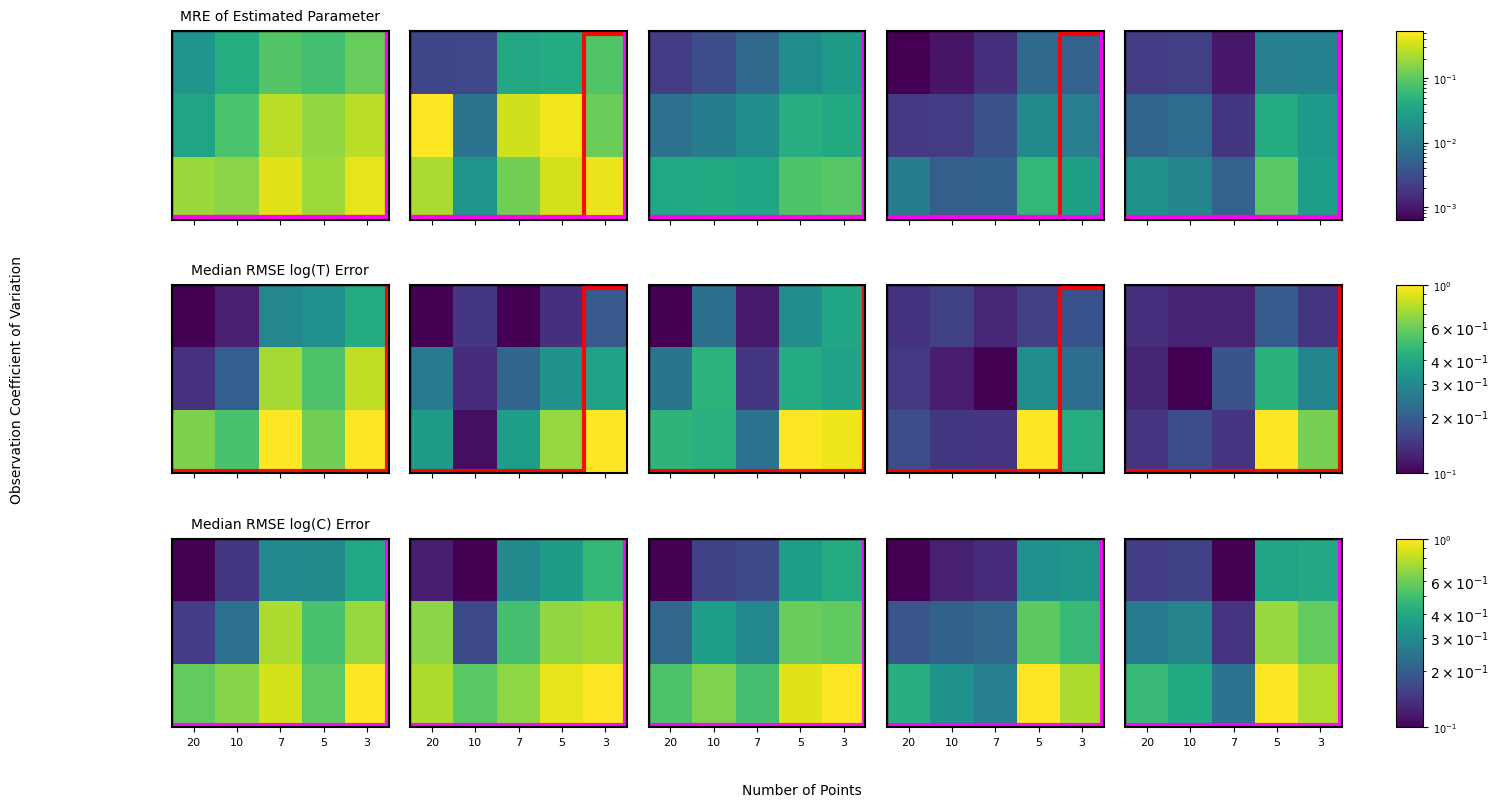

In [23]:
# Cell 3: Plotting for all_params, CR only ("toprightGemini")
# Ensure Cell 1C (with plot_figure_cell3) and Cell 2 are executed before this.
use_log_scale_cell3 = True 
print(f"\n--- Plotting Cell 3 Figure (3x5, 1 Cbar per Row) ---")

plot_figure_cell3( 
    all_params_list=all_params,
    aggregated_data_map=aggregated_data_storage,
    row_bounds_dict=cmap_bounds_CR_only, 
    log_scale=use_log_scale_cell3,
    save_path="poster_images/toprightGemini/combined_figure_all_params_CR.png"
)


--- Plotting Cell 4 Figure (2x3 Total, 1 Cbar per Column) ---


/var/folders/8y/57d0gjj96nz3fb3db518g2kr0000gn/T/ipykernel_35974/158131820.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.2, h_pad=0.3, w_pad=0.2) # Very tight padding


Saved Cell4 to poster_images/middlerightGemini/combined_figure_NR_params_2x3.png


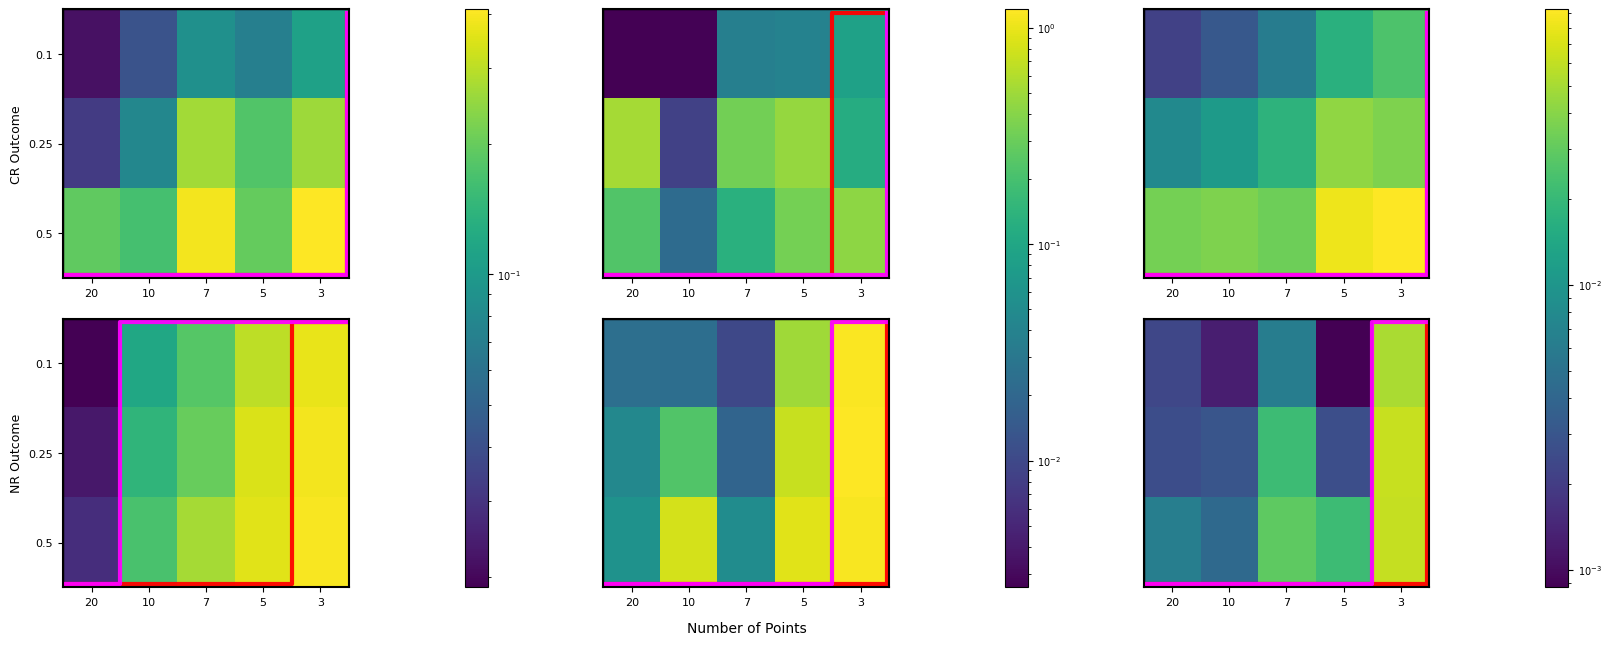

In [24]:
# Cell 4: Plotting for params_with_NRs ("middlerightGemini")
# Ensure Cell 1C (with plot_figure_cell4) and Cell 2 are executed before this.
use_log_scale_cell4 = True 
print(f"\n--- Plotting Cell 4 Figure (2x3 Total, 1 Cbar per Column) ---")

plot_figure_cell4( 
    params_for_cols_list=params_with_NRs, 
    aggregated_data_map=aggregated_data_storage,
    metric_to_plot_template="param_relative_err_{outcome}", 
    log_scale=use_log_scale_cell4,
    save_path="poster_images/middlerightGemini/combined_figure_NR_params_2x3.png"
)